In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import cv2
import numpy as np

dataset_path = '/content/drive/MyDrive/gwbz3fsgp8-2'

images = []
labels = []

def crop_to_graph_area(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY_INV)


    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return image

    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)
    cropped = image[y:y+h, x:x+w]
    return cropped

for label in os.listdir(dataset_path):
    label_folder = os.path.join(dataset_path, label)
    if os.path.isdir(label_folder):
        for filename in os.listdir(label_folder):
            if filename.lower().endswith(('.jpg', '.png', '.jpeg')):
                file_path = os.path.join(label_folder, filename)
                img = cv2.imread(file_path)

                cropped = crop_to_graph_area(img)

                gray = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)
                enhanced = cv2.equalizeHist(gray)
                resized = cv2.resize(enhanced, (128, 128))

                images.append(resized)
                labels.append(label)

images = np.array(images)
labels = np.array(labels)

print("Processed images shape:", images.shape)
print("Labels found:", set(labels))


Processed images shape: (948, 128, 128)
Labels found: {np.str_('Normal Person ECG Images (284x12=3408)'), np.str_('ECG Images of Patient that have abnormal heartbeat (233x12=2796)'), np.str_('ECG Images of Myocardial Infarction Patients (240x12=2880)'), np.str_('ECG Images of Patient that have History of MI (172x12=2064)')}


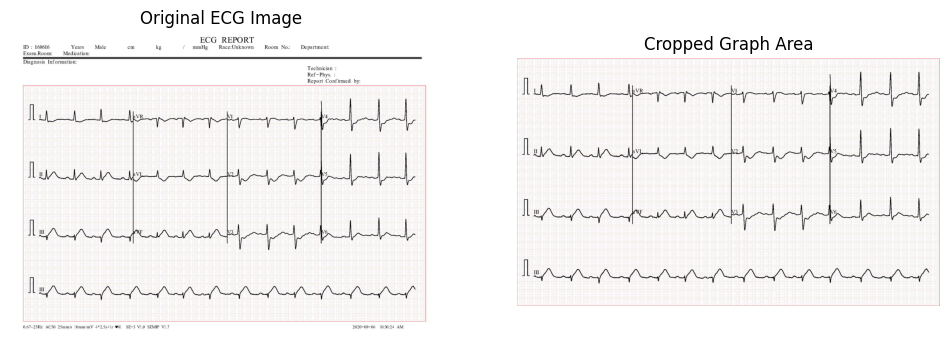

In [ ]:
import cv2
import matplotlib.pyplot as plt

example_image_path = '/content/drive/MyDrive/gwbz3fsgp8-2/ECG Images of Myocardial Infarction Patients (240x12=2880)/MI(1).jpg'

original_img = cv2.imread(example_image_path)

def crop_to_graph_area(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY_INV)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return image

    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)
    cropped = image[y:y+h, x:x+w]
    return cropped

cropped_img = crop_to_graph_area(original_img)

original_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
cropped_rgb = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title('Original ECG Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cropped_rgb)
plt.title('Cropped Graph Area')
plt.axis('off')

plt.show()


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

dataset_path = '/content/drive/MyDrive/gwbz3fsgp8-2'

output_path = '/content/drive/MyDrive/gwbz3fsgp8-2_cleaned'
os.makedirs(output_path, exist_ok=True)


def crop_to_graph_area(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return image
    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)
    return image[y:y+h, x:x+w]

def remove_grid_lines_fft(image_gray):
    f = np.fft.fft2(image_gray)
    fshift = np.fft.fftshift(f)

    rows, cols = image_gray.shape
    crow, ccol = rows // 2 , cols // 2

    mask = np.ones((rows, cols), np.uint8)
    mask[crow-5:crow+5, :] = 0
    mask[:, ccol-5:ccol+5] = 0

    fshift_filtered = fshift * mask
    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)
    img_back = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    return img_back

def apply_wave_mask_to_color(cropped_color, cleaned_gray):
    mask = cleaned_gray / 255.0
    mask_3ch = np.stack([mask]*3, axis=-1)
    wave_color = (cropped_color * mask_3ch).astype(np.uint8)
    return wave_color


for label in tqdm(os.listdir(dataset_path), desc="Processing classes"):
    label_folder = os.path.join(dataset_path, label)
    if not os.path.isdir(label_folder):
        continue

    output_label_folder = os.path.join(output_path, label)
    os.makedirs(output_label_folder, exist_ok=True)

    for filename in os.listdir(label_folder):
        if filename.lower().endswith(('.jpg', '.png', '.jpeg')):
            file_path = os.path.join(label_folder, filename)
            img = cv2.imread(file_path)

            try:
                cropped = crop_to_graph_area(img)
                gray = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)
                no_grid = remove_grid_lines_fft(gray)
                colored_wave = apply_wave_mask_to_color(cropped, no_grid)

                save_path = os.path.join(output_label_folder, filename)
                cv2.imwrite(save_path, colored_wave)
            except Exception as e:
                print(f"Failed on {file_path}: {e}")


Processing classes: 100%|██████████| 5/5 [11:58<00:00, 143.65s/it]


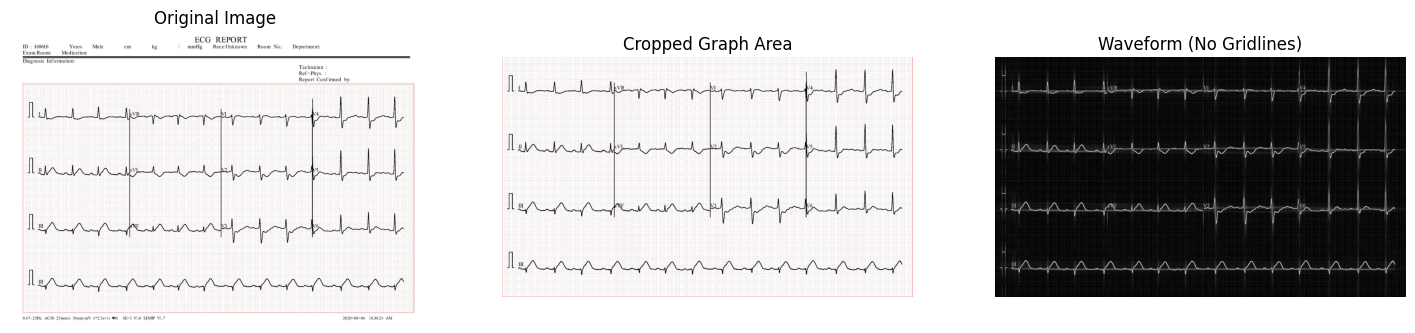

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

example_image_path = '/content/drive/MyDrive/gwbz3fsgp8-2/ECG Images of Myocardial Infarction Patients (240x12=2880)/MI(1).jpg'
original_img = cv2.imread(example_image_path)

def crop_to_graph_area(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return image
    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)
    return image[y:y+h, x:x+w]

def remove_grid_lines_fft(image_gray):
    f = np.fft.fft2(image_gray)
    fshift = np.fft.fftshift(f)

    rows, cols = image_gray.shape
    crow, ccol = rows // 2 , cols // 2

    mask = np.ones((rows, cols), np.uint8)
    mask[crow-5:crow+5, :] = 0
    mask[:, ccol-5:ccol+5] = 0

    fshift_filtered = fshift * mask
    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)
    img_back = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    return img_back

cropped_img = crop_to_graph_area(original_img)

gray = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2GRAY)

wave_only = remove_grid_lines_fft(gray)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB))
plt.title('Cropped Graph Area')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(wave_only, cmap='gray')
plt.title('Waveform (No Gridlines)')
plt.axis('off')

plt.show()
